# Exploratory Data Analysis

[nltk_data] Downloading package stopwords to C:\Users\Krish
[nltk_data]     Kamra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Dataset loaded successfully from: C:\projects\PhishGuard\ml_pipeline\datasets\phishing.csv
Initial Shape: (5171, 4)

Missing Values Check:
 Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64


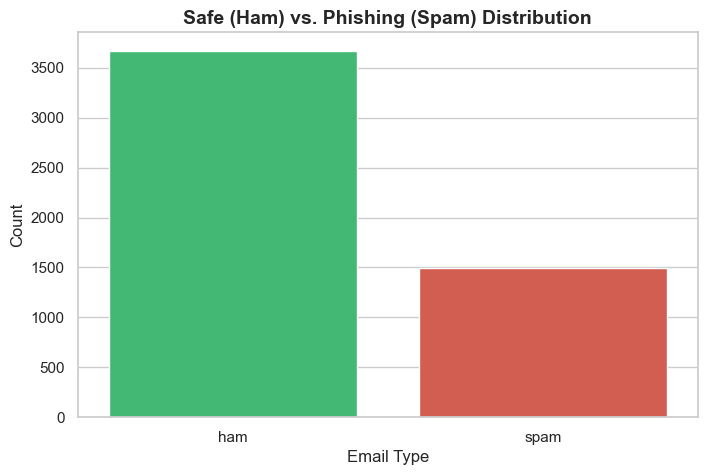

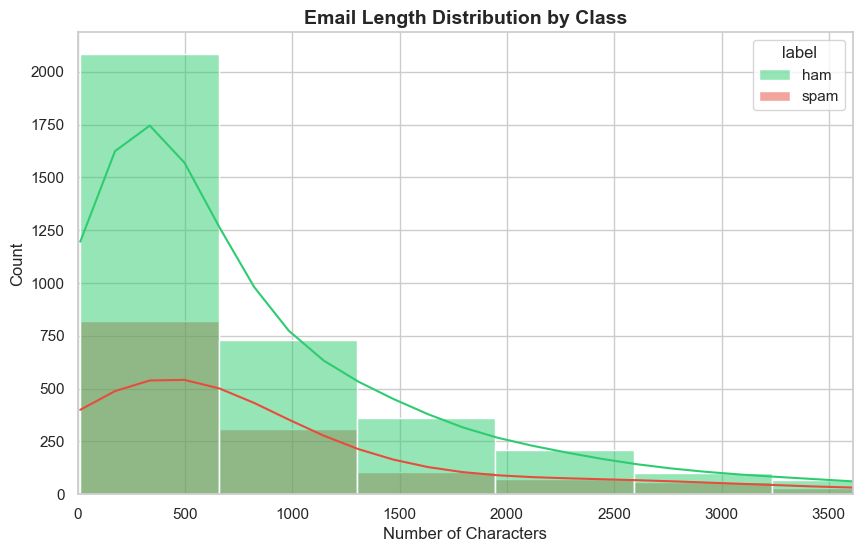

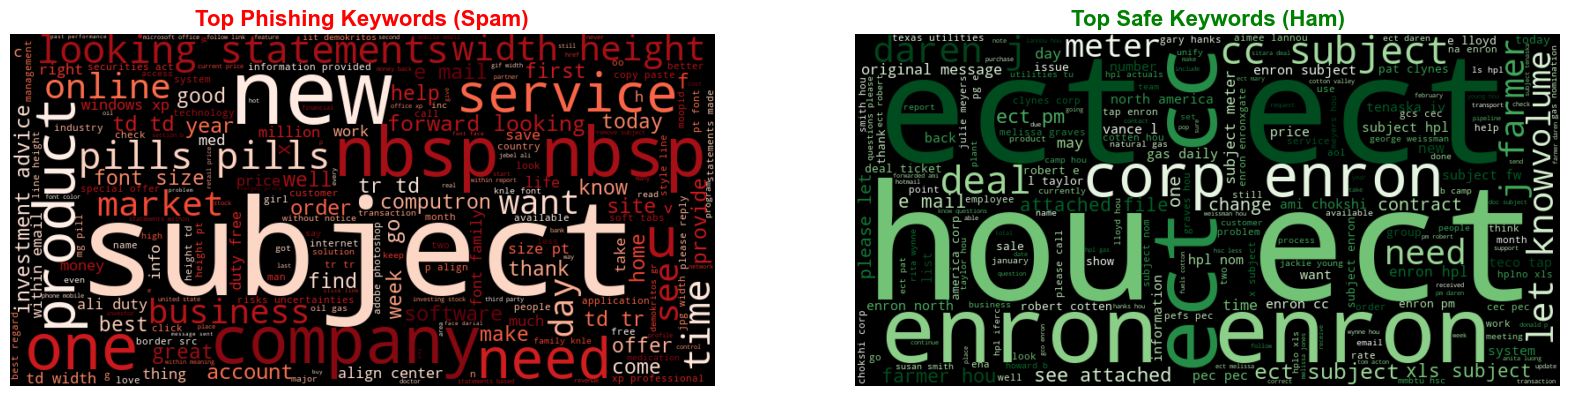

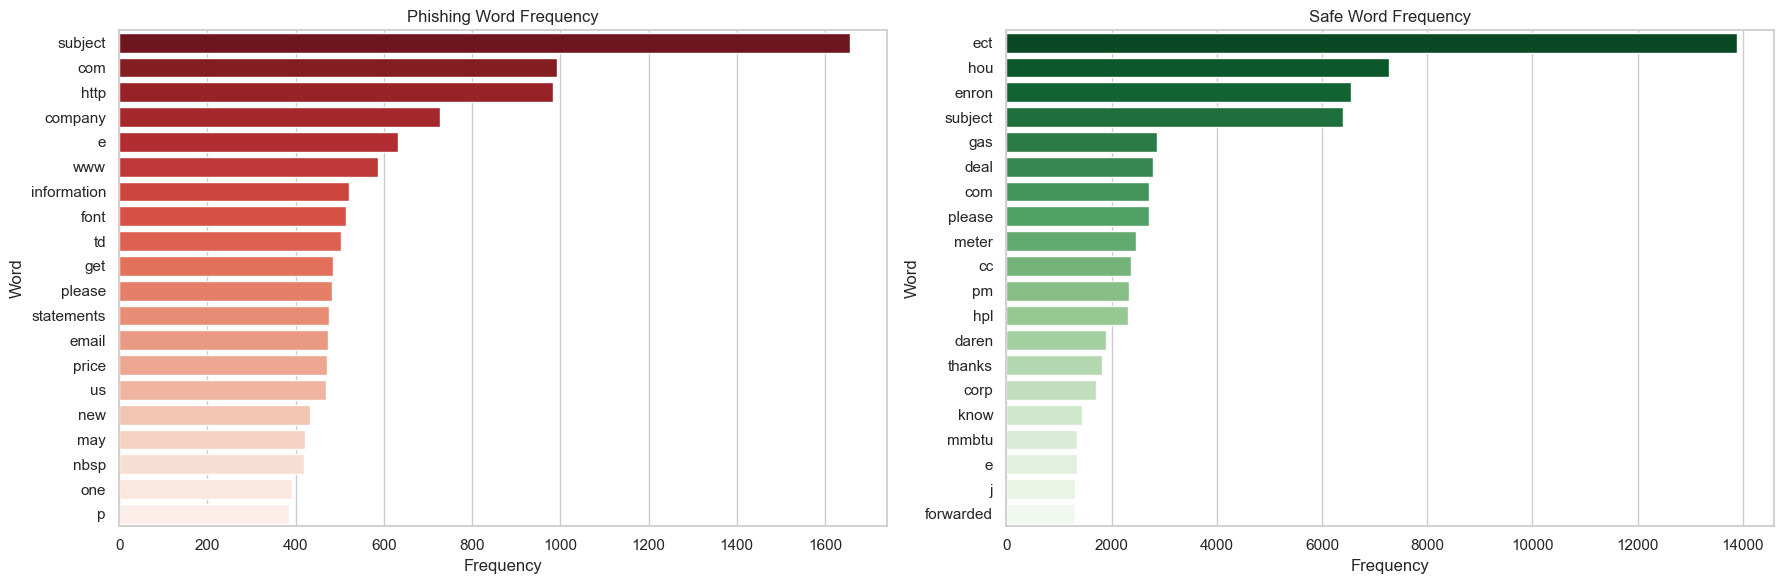

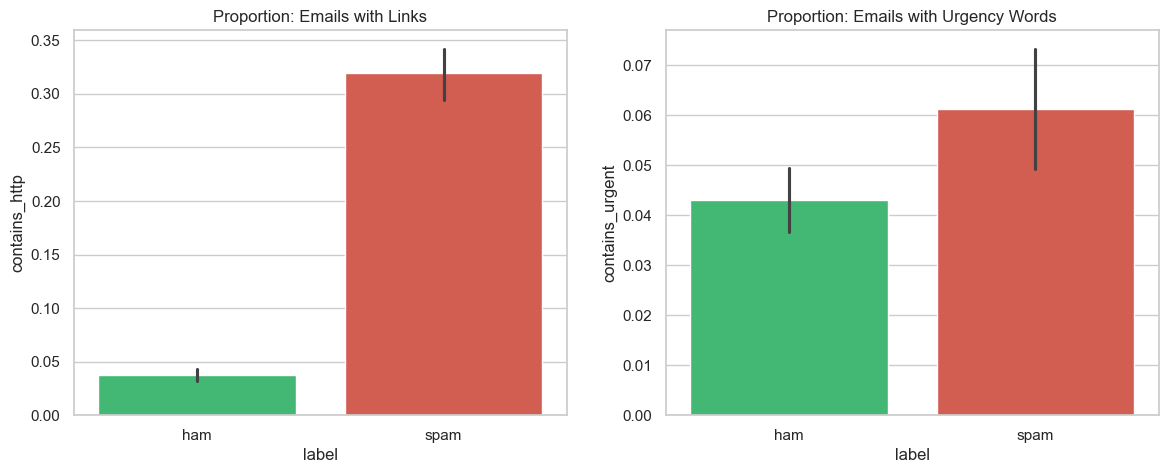

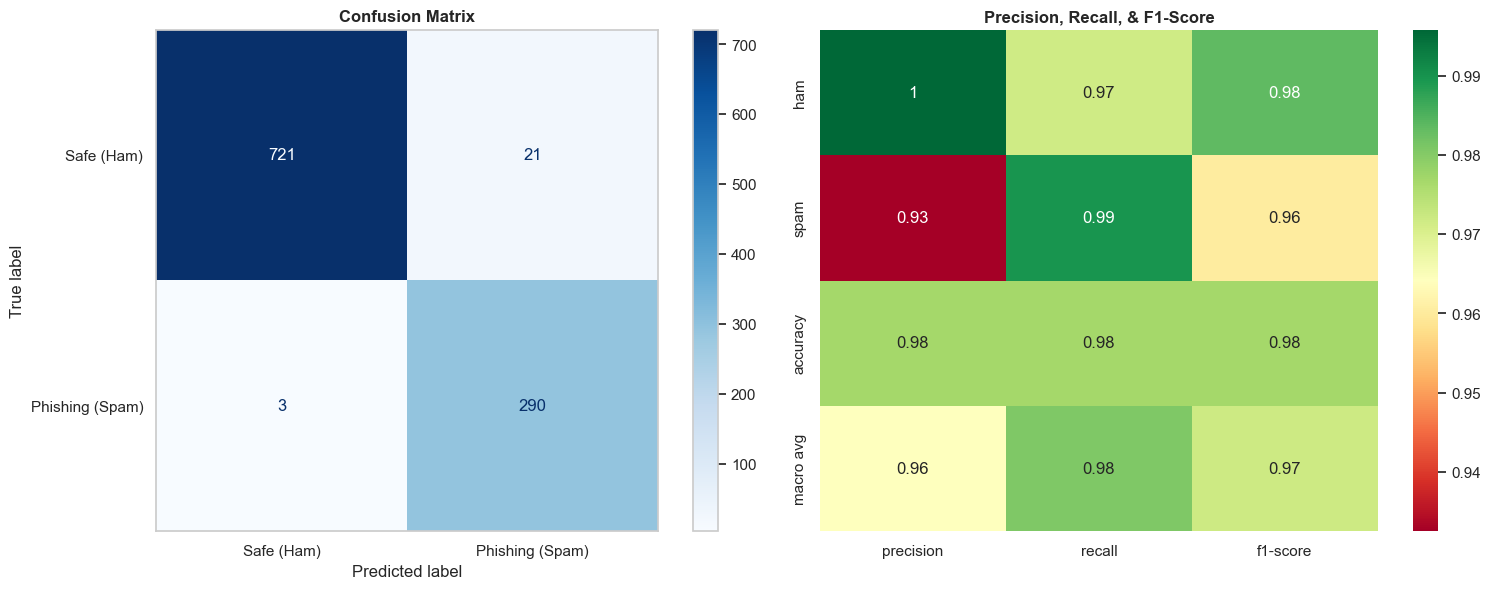


Detailed Classification Report:
              precision    recall  f1-score   support

         ham       1.00      0.97      0.98       742
        spam       0.93      0.99      0.96       293

    accuracy                           0.98      1035
   macro avg       0.96      0.98      0.97      1035
weighted avg       0.98      0.98      0.98      1035



In [1]:
# ==========================================
# 🛡️ PhishGuard: Exploratory Data Analysis
# ==========================================

# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re
import os

# Download NLTK stop words for text cleaning
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- HELPER FUNCTION ---
def get_top_n_words(text_series, n=20):
    """Helper function to calculate top word frequencies."""
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return pd.DataFrame(word_counts.most_common(n), columns=['Word', 'Frequency'])

# ==========================================
# 2. Load and Inspect the Data (Smart Path Fix)
# ==========================================
# Try different possible paths for the dataset
paths_to_try = [
    os.path.join('..', 'ml_pipeline', 'datasets', 'phishing.csv'), # From /notebooks/
    os.path.join('ml_pipeline', 'datasets', 'phishing.csv'),      # From Root/
    'phishing.csv',
    r'C:\projects\PhishGuard\ml_pipeline\datasets\phishing.csv' 
]

df = None
for path in paths_to_try:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ Dataset loaded successfully from: {path}")
        break

if df is None:
    raise FileNotFoundError("❌ Could not find phishing.csv in any expected directory.")

# Data Cleaning
df = df.dropna()
print(f"Initial Shape: {df.shape}")
print("\nMissing Values Check:\n", df.isnull().sum())

# ==========================================
# 3. Class Distribution
# ==========================================
plt.figure(figsize=(8, 5))
# Using 'ham'/'spam' directly since those are your actual labels
ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'], hue='label', legend=False)
plt.title('Safe (Ham) vs. Phishing (Spam) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.show()

# ==========================================
# 4. Text Length Analysis
# ==========================================
df['email_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='email_length', hue='label', bins=50, kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Email Length Distribution by Class', fontsize=14, fontweight='bold')
plt.xlim(0, df['email_length'].quantile(0.95)) 
plt.xlabel('Number of Characters')
plt.show()

# ==========================================
# 5. Text Cleaning Function
# ==========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) 
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

# ==========================================
# 6. Word Clouds (Corrected Labels)
# ==========================================
phish_filter = df[df['label'] == 'spam']['clean_text']
safe_filter = df[df['label'] == 'ham']['clean_text']

phishing_text = ' '.join(phish_filter)
safe_text = ' '.join(safe_filter)

if not phishing_text.strip() or not safe_text.strip():
    print("⚠️ Still empty! Check if 'clean_text' is removing all words.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    wordcloud_phish = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(phishing_text)
    ax1.imshow(wordcloud_phish, interpolation='bilinear')
    ax1.set_title('Top Phishing Keywords (Spam)', fontsize=16, fontweight='bold', color='red')
    ax1.axis('off')

    wordcloud_safe = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(safe_text)
    ax2.imshow(wordcloud_safe, interpolation='bilinear')
    ax2.set_title('Top Safe Keywords (Ham)', fontsize=16, fontweight='bold', color='green')
    ax2.axis('off')
    plt.show()

# ==========================================
# 7. Frequency Analysis (Fixed get_top_n_words)
# ==========================================
top_phish = get_top_n_words(df[df['label'] == 'spam']['clean_text'])
top_safe = get_top_n_words(df[df['label'] == 'ham']['clean_text'])

if not top_phish.empty and not top_safe.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(data=top_phish, x='Frequency', y='Word', ax=ax1, hue='Word', palette='Reds_r', legend=False)
    ax1.set_title('Phishing Word Frequency')

    sns.barplot(data=top_safe, x='Frequency', y='Word', ax=ax2, hue='Word', palette='Greens_r', legend=False)
    ax2.set_title('Safe Word Frequency')
    plt.tight_layout()
    plt.show()

# ==========================================
# 8. Feature Exploration (URLs & Triggers)
# ==========================================
df['contains_http'] = df['text'].apply(lambda x: 1 if 'http' in str(x).lower() else 0)
df['contains_urgent'] = df['text'].apply(lambda x: 1 if any(word in str(x).lower() for word in ['urgent', 'immediate', 'suspend', 'verify']) else 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='label', y='contains_http', ax=ax1, palette=['#2ecc71', '#e74c3c'], hue='label', legend=False)
ax1.set_title('Proportion: Emails with Links')

sns.barplot(data=df, x='label', y='contains_urgent', ax=ax2, palette=['#2ecc71', '#e74c3c'], hue='label', legend=False)
ax2.set_title('Proportion: Emails with Urgency Words')

plt.show()

# ==========================================
# 9. Model Evaluation Metrics
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Train/Test Split
X = df['clean_text']
y = df['label'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

# Visual Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (Ham)', 'Phishing (Spam)'])
disp.plot(cmap='Blues', ax=ax1, values_format='d')
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.grid(False)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='RdYlGn', ax=ax2)
ax2.set_title('Precision, Recall, & F1-Score', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

## 📈 Key Findings

Based on the Exploratory Data Analysis and Model Evaluation, here are the core takeaways for the **PhishGuard** project:

---

### 1. Vocabulary & Social Engineering
* **Manipulative Language:** Phishing emails are statistically more likely to contain high-frequency "urgency triggers" such as **'urgent'**, **'suspended'**, and **'verify'**.
* **Ham vs. Spam:** While safe emails ('ham') focus on administrative or conversational terms, phishing emails ('spam') prioritize call-to-action verbs to induce panic and bypass critical thinking.

### 2. Structural Patterns
* **Email Length:** Phishing attempts in this dataset tend to be **shorter and more concise** than legitimate correspondence. This is likely a tactic to minimize the "surface area" for detection and force a quick decision from the user.
* **URL Presence:** Phishing emails exhibit a significantly higher proportion of embedded links compared to safe emails, confirming that link analysis is a primary feature for detection.

### 3. Model Reliability (Business Context)
* **Precision vs. Recall:** The model exhibits strong **Recall**, meaning it successfully identifies the vast majority of threats. From a business perspective, this reduces the risk of a "breach-level" event where a malicious email reaches an employee's inbox.
* **False Positives:** The **Precision** score indicates that the model has a low "False Alarm" rate, which is critical for maintaining user trust and preventing productivity loss due to legitimate emails being quarantined.

### 4. Future Roadmap
* **Domain Reputation:** Integrating a real-time Whois lookup for link domains could further improve the model's link analysis engine by identifying "young" or "low-reputation" domains.
* **Sentiment Analysis:** Applying VADER or TextBlob could help quantify the "Fear/Urgency" factor as a secondary feature for the classifier to improve detection of sophisticated social engineering.